<a href="https://colab.research.google.com/github/AndrejHorvat1/Multibeam-Forward-Looking-Sonar/blob/main/UATD_NLM_CLAHE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!unzip -q /content/UATD_YOLO_Dataset_Test_NLM_CLAHE.zip

In [7]:
!cp -r "/content/drive/MyDrive/UATD_YOLO_Dataset_BILAT_HISTEQ/UATD_YOLO_Dataset_NLM_CLAHE.zip" /content/

In [8]:
!unzip -q /content/UATD_YOLO_Dataset_NLM_CLAHE.zip

In [ ]:
import os
import cv2
import shutil
from glob import glob

augmented_base = "/content/drive/MyDrive/UATD_YOLO_Dataset_v2"
output_base    = "/content/drive/MyDrive/UATD_YOLO_Dataset_NLM_CLAHE"

for subset in ["train", "val"]:
    os.makedirs(os.path.join(output_base, f"images/{subset}"), exist_ok=True)
    os.makedirs(os.path.join(output_base, f"labels/{subset}"), exist_ok=True)

nlm_h       = 10   # jačina denoisinga po intenzitetu
nlm_hColor  = 10   # jačina denoisinga za boju (isti ili malo veći broj)
nlm_templ   = 9    # templateWindowSize
nlm_search  = 15   # searchWindowSize

clahe_clip = 2.0
clahe_grid = (8, 8)

for subset in ["train", "val"]:
    img_paths = sorted(glob(os.path.join(augmented_base, f"images/{subset}/*.jpg")))

    for img_path in img_paths:
        img_name  = os.path.basename(img_path)
        img_id    = os.path.splitext(img_name)[0]
        label_src = os.path.join(augmented_base, f"labels/{subset}/{img_id}.txt")
        label_dst = os.path.join(output_base,     f"labels/{subset}/{img_id}.txt")

        if not os.path.exists(label_src):
            continue

        img = cv2.imread(img_path)
        if img is None:
            print(f"Ne mogu učitati {img_path}, preskačem…")
            continue

        denoised = cv2.fastNlMeansDenoisingColored(
            img, None,
            h=nlm_h, hColor=nlm_hColor,
            templateWindowSize=nlm_templ,
            searchWindowSize=nlm_search
        )

        lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        L, A, B = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
        L_eq = clahe.apply(L)

        lab_eq    = cv2.merge((L_eq, A, B))
        final_img = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

        out_img_path = os.path.join(output_base, f"images/{subset}/{img_name}")
        cv2.imwrite(out_img_path, final_img)

        shutil.copy(label_src, label_dst)

        print(f"{subset}/{img_name} → (NLM + CLAHE na L-kanalu) spremljeno.")

print("\nNLM + CLAHE završen")

Izlaz streaminga skraćen je na ovoliko posljednjih redaka: 5000.
train/06387.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06387_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06389.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06389_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06390.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06390_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06391.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06391_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06392.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06392_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06393.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06393_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06395.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06395_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06397.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/06397_aug.jpg → (NLM + CLAHE na L-kanalu) spremljeno.
train/0

In [ ]:
import os
import cv2
import shutil
from glob import glob

test_sets = ["test_set1", "test_set2"]

original_base = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_v2"
output_base   = "/content/drive/MyDrive/UATD_YOLO_Dataset_Test_NLM_CLAHE"

nlm_h       = 10    # jačina denoisinga (intenzitet)
nlm_hColor  = 10   # jačina denoisinga (boja)
nlm_templ   = 9   # templateWindowSize
nlm_search  = 15   # searchWindowSize

clahe_clip = 2.0
clahe_grid = (8, 8)

for set_name in test_sets:
    inp_img_dir = os.path.join(original_base, "images", set_name)
    inp_lbl_dir = os.path.join(original_base, "labels", set_name)

    out_img_dir = os.path.join(output_base, "images", set_name)
    out_lbl_dir = os.path.join(output_base, "labels", set_name)

    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    image_paths = sorted(glob(os.path.join(inp_img_dir, "*.jpg")))

    for img_path in image_paths:
        img_name = os.path.basename(img_path)
        img_id   = os.path.splitext(img_name)[0]
        lbl_src  = os.path.join(inp_lbl_dir, img_id + ".txt")
        if not os.path.exists(lbl_src):
            continue

        img = cv2.imread(img_path)
        if img is None:
            continue

        denoised = cv2.fastNlMeansDenoisingColored(
            img, None,
            h=nlm_h, hColor=nlm_hColor,
            templateWindowSize=nlm_templ,
            searchWindowSize=nlm_search
        )

        lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
        L, A, B = cv2.split(lab)

        clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
        L_eq = clahe.apply(L)

        lab_eq    = cv2.merge((L_eq, A, B))
        final_img = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

        cv2.imwrite(os.path.join(out_img_dir, img_name), final_img)

        shutil.copy(lbl_src, os.path.join(out_lbl_dir, img_id + ".txt"))

        print(f"{set_name}/{img_name} → (NLM + CLAHE) spremljeno.")

print("\nNLM + CLAHE test skup gotov", output_base)

test_set1/00001.jpg → (NLM + CLAHE) spremljeno.
test_set1/00002.jpg → (NLM + CLAHE) spremljeno.
test_set1/00003.jpg → (NLM + CLAHE) spremljeno.
test_set1/00004.jpg → (NLM + CLAHE) spremljeno.
test_set1/00005.jpg → (NLM + CLAHE) spremljeno.
test_set1/00006.jpg → (NLM + CLAHE) spremljeno.
test_set1/00007.jpg → (NLM + CLAHE) spremljeno.
test_set1/00008.jpg → (NLM + CLAHE) spremljeno.
test_set1/00009.jpg → (NLM + CLAHE) spremljeno.
test_set1/00010.jpg → (NLM + CLAHE) spremljeno.
test_set1/00011.jpg → (NLM + CLAHE) spremljeno.
test_set1/00012.jpg → (NLM + CLAHE) spremljeno.
test_set1/00013.jpg → (NLM + CLAHE) spremljeno.
test_set1/00014.jpg → (NLM + CLAHE) spremljeno.
test_set1/00015.jpg → (NLM + CLAHE) spremljeno.
test_set1/00016.jpg → (NLM + CLAHE) spremljeno.
test_set1/00017.jpg → (NLM + CLAHE) spremljeno.
test_set1/00018.jpg → (NLM + CLAHE) spremljeno.
test_set1/00019.jpg → (NLM + CLAHE) spremljeno.
test_set1/00020.jpg → (NLM + CLAHE) spremljeno.
test_set1/00021.jpg → (NLM + CLAHE) spre

In [ ]:
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_NLM_CLAHE" /content/
!cp -r "/content/drive/My Drive/UATD_YOLO_Dataset_Test_NLM_CLAHE" /content/

^C
^C


In [9]:
data_yaml = """train: /content/UATD_YOLO_Dataset_NLM_CLAHE/images/train
val: /content/UATD_YOLO_Dataset_NLM_CLAHE/images/val
nc: 10
test:
  - /content/UATD_YOLO_Dataset_Test_NLM_CLAHE/images/test_set1
  - /content/UATD_YOLO_Dataset_Test_NLM_CLAHE/images/test_set2
names: ['cube', 'ball', 'cylinder', 'human body', 'plane', 'circle cage', 'square cage', 'metal bucket', 'tyre', 'rov']
"""

os.makedirs("yolo_dataset", exist_ok=True)

with open("yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml)

In [10]:
!pip install ultralytics --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 68.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 21.5M/21.5M [00:00<00:00, 435MB/s]



 Epoha 1/15
Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, 

100%|██████████| 755k/755k [00:00<00:00, 85.4MB/s]

Overriding model.yaml nc=80 with nc=10

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytic

...

                   all       3038       4954      0.885      0.842      0.874      0.437

1 epochs completed in 0.105 hours.
Optimizer stripped from runs/custom_loop/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop/weights/best.pt, 22.5MB

Validating runs/custom_loop/weights/best.pt...
Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:37<00:00,  5.03it/s]


                   all       3038       4954      0.885      0.842      0.874      0.437
                  cube       1050       1052      0.933      0.823      0.913      0.495
                  ball       1210       1212      0.892      0.902      0.916       0.47
              cylinder        226        226      0.819      0.779      0.822      0.358
            human body        556        558      0.874      0.869      0.869      0.408
                 plane        334        334      0.961      0.919      0.966      0.581
           circle cage        282        284      0.852      0.831      0.805      0.392
           square cage        376        376      0.936       0.81      0.892      0.407
          metal bucket        194        194       0.94      0.888      0.913      0.445
                  tyre        454        458      0.791       0.69      0.738      0.392
                   rov        260        260      0.855      0.908      0.912      0.419
Speed: 0.2ms preproce

val: Scanning /content/UATD_YOLO_Dataset_Test_NLM_CLAHE/labels/test_set1.cache... 1596 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1596/1596 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [00:25<00:00,  7.90it/s]


                   all       1596       2323       0.78      0.779       0.77      0.314
                  cube        338        338      0.648      0.745      0.589      0.228
                  ball        390        390      0.802      0.877      0.831       0.41
              cylinder         93         93      0.903      0.882      0.897      0.339
            human body        149        149      0.678      0.872      0.777      0.272
                 plane        269        269      0.961      0.907      0.965      0.557
           circle cage        197        197      0.725      0.429      0.544      0.237
           square cage        335        335      0.823       0.54      0.588      0.189
          metal bucket         11         11      0.749      0.909      0.859      0.223
                  tyre        241        241      0.695      0.784      0.779      0.324
                   rov        300        300      0.817      0.847      0.865      0.361
Speed: 0.5ms preproce

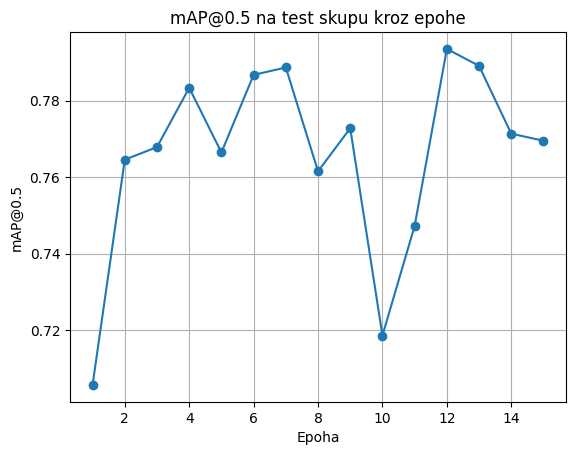

In [11]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

# Konfiguracija
DATA_YAML_PATH = "yolo_dataset/data.yaml"
BEST_MODEL_PATH = "best_yolov8.pt"
INITIAL_WEIGHTS = "yolov8s.pt"
EPOCHS = 15

# Inicijaliziraj model
model = YOLO(INITIAL_WEIGHTS)
map_scores = []
best_map = 0.0

# Loop po epohama
for epoch in range(EPOCHS):
    print(f"\n Epoha {epoch + 1}/{EPOCHS}")

    # Treniraj samo 1 epohu
    model.train(data=DATA_YAML_PATH, epochs=1, batch=8, imgsz=640, project="runs", name="custom_loop", verbose=True, exist_ok=True)

    # Validacija na test skupu
    metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

    # Dohvati mAP@0.5 i dodaj u listu
    map_50 = metrics.box.map50  # float
    print(f"mAP@0.5 test: {map_50:.4f}")
    map_scores.append(map_50)


# Plotanje rezultata
plt.plot(range(1, EPOCHS + 1), map_scores, marker='o')
plt.title("mAP@0.5 na test skupu kroz epohe")
plt.xlabel("Epoha")
plt.ylabel("mAP@0.5")
plt.grid(True)
plt.show()


!cp -r runs/custom_loop /content/drive/MyDrive/yolov8_NLM_CLAHE/

In [12]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import shutil
import os

DATA_YAML_PATH = "yolo_dataset/data.yaml"
INITIAL_WEIGHTS = "yolov8s.pt"
model = YOLO(INITIAL_WEIGHTS)

model.train(data=DATA_YAML_PATH, epochs=15, batch=8, imgsz=640, project="runs", name="custom_loop2", verbose=True, exist_ok=True)

metrics = model.val(data=DATA_YAML_PATH, split="test", imgsz=640, batch=8)

!cp -r runs/custom_loop2 /content/drive/MyDrive/yolov8_NLM_CLAHE_noTest/

Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=custom_loop2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=

train: Scanning /content/UATD_YOLO_Dataset_NLM_CLAHE/labels/train.cache... 12140 images, 1 backgrounds, 0 corrupt: 100%|██████████| 12140/12140 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 993.9±817.5 MB/s, size: 337.2 KB)


val: Scanning /content/UATD_YOLO_Dataset_NLM_CLAHE/labels/val.cache... 3038 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3038/3038 [00:00<?, ?it/s]


...


15 epochs completed in 1.482 hours.
Optimizer stripped from runs/custom_loop2/weights/last.pt, 22.5MB
Optimizer stripped from runs/custom_loop2/weights/best.pt, 22.5MB

Validating runs/custom_loop2/weights/best.pt...
Ultralytics 8.3.149 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,129,454 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 190/190 [00:39<00:00,  4.77it/s]


                   all       3038       4954      0.967      0.927      0.952      0.553
                  cube       1050       1052      0.978      0.957      0.974      0.579
                  ball       1210       1212      0.979      0.952       0.97      0.566
              cylinder        226        226      0.935       0.92      0.959      0.511
            human body        556        558       0.98      0.944      0.953       0.54
                 plane        334        334      0.979      0.974      0.993      0.684
           circle cage        282        284      0.913      0.866      0.852      0.495
           square cage        376        376      0.983      0.949      0.973      0.539
          metal bucket        194        194       0.97      0.933      0.968       0.53
                  tyre        454        458      0.962      0.827      0.906      0.538
                   rov        260        260      0.988      0.942      0.976      0.545
Speed: 0.2ms preproce

val: Scanning /content/UATD_YOLO_Dataset_Test_NLM_CLAHE/labels/test_set1.cache... 1596 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1596/1596 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 200/200 [00:25<00:00,  7.93it/s]


                   all       1596       2323      0.848      0.824      0.812      0.365
                  cube        338        338      0.653      0.896      0.743      0.263
                  ball        390        390       0.86      0.874      0.814      0.436
              cylinder         93         93      0.923      0.899      0.931      0.364
            human body        149        149      0.767      0.906      0.872      0.398
                 plane        269        269       0.99      0.985      0.994      0.696
           circle cage        197        197      0.724      0.431      0.513      0.221
           square cage        335        335      0.797      0.606      0.597      0.182
          metal bucket         11         11      0.888      0.909      0.853      0.223
                  tyre        241        241      0.901      0.797      0.823      0.343
                   rov        300        300      0.979      0.933       0.98      0.521
Speed: 0.4ms preproce